In [1]:
import sys

sys.path.insert(0, '/home/caron/Bureau/ST-GNN-for-wildifre-prediction/Prediction')
sys.path.insert(0, '/home/caron/Bureau/ST-GNN-for-wildifre-prediction/Prediction/GNN')

from tools import *

/home/caron/anaconda3/envs/venv-3.9/lib/python3.9/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/home/caron/anaconda3/envs/venv-3.9/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Nom de l'hôte : caron-Precision-7780
Adresse IP locale : 127.0.1.1
Nom de l'hôte : caron-Precision-7780
Adresse IP locale : 127.0.1.1


In [ ]:
#model = pickle.load(open('bdiff/firepoint/2x2/train/occurence_default/check_z-score/full_all_departement_0_None_node/alafederated-GRU-departement-fltg_search_full_10_0_all_one_nbsinister-kmeans-5-Class-Dept_classification_wkloss/alafederated-GRU-departement-fltg_search_full_10_0_all_one_nbsinister-kmeans-5-Class-Dept_classification_wkloss.pkl', 'rb'))

In [3]:
model = pickle.load(open('firemen/firepoint/2x2/train/occurence_default/check_z-score/full_all_departement_0_None_node/TFN_full_full_10_0_all_one_nbsinister-kmeans-5-Class-Dept_classification_flwki-id{departement}/TFN_full_full_10_0_all_one_nbsinister-kmeans-5-Class-Dept_classification_flwki-id{departement}.pkl', 'rb'))

In [4]:
model.model

TemporalFusionTransformerClassifier(
  (vsn): VariableSelectionNetwork(
    (var_grns): ModuleList(
      (0-110): 111 x GatedResidualNetwork(
        (fc1): Linear(in_features=1, out_features=512, bias=True)
        (act): ReLU()
        (dropout): Dropout(p=0.1, inplace=False)
        (fc2): Linear(in_features=512, out_features=256, bias=True)
        (skip): Linear(in_features=1, out_features=256, bias=True)
        (glu): GLU(
          (fc_a): Linear(in_features=256, out_features=256, bias=True)
          (fc_b): Linear(in_features=256, out_features=256, bias=True)
        )
        (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      )
    )
    (selection_grn): GatedResidualNetwork(
      (fc1): Linear(in_features=111, out_features=512, bias=True)
      (act): ReLU()
      (dropout): Dropout(p=0.1, inplace=False)
      (fc2): Linear(in_features=512, out_features=111, bias=True)
      (skip): Identity()
      (glu): GLU(
        (fc_a): Linear(in_features=111, out_

In [ ]:
small_df = model.df_test[model.df_test['departement'] == 6]

x, y =  model.predict(small_df, return_y=True)

In [17]:
test_loader = model.create_test_loader(model.graph, small_df)

In [66]:
model.model.eval()

with torch.no_grad():

    for _, data in enumerate(test_loader, 0):
        inputs, orilabels_, _ = data
        for H in range(model.horizon + 1):
            orilabels = orilabels_[:, :, -1 - (model.horizon - H)]
            orilabels[:, -1] = orilabels[:,  -1 ] > 0 if model.task_type == 'binary' else orilabels[:,  -1 ]
            inputs_horizon = model.compute_inputs(inputs,  -1 - (model.horizon - H), "current" if H == 0 else "futur")
            
            
            output, logits, hidden = model.model(inputs_horizon, z_prev=None, return_extras=True)
    

In [67]:
model.model.static_idx.shape[0] + model.model.temporal_idx.shape[0]

136

In [68]:
temporal_feature = [model.features_name[id] for id in model.model.temporal_idx]

In [69]:
average_sel = hidden['vsn_weights'].mean(dim=(0, 1)).detach().numpy()

In [70]:
hidden['vsn_weights'].mean(dim=(0, 1)).max()

tensor(0.055)

In [71]:
average_sel.shape

(111,)

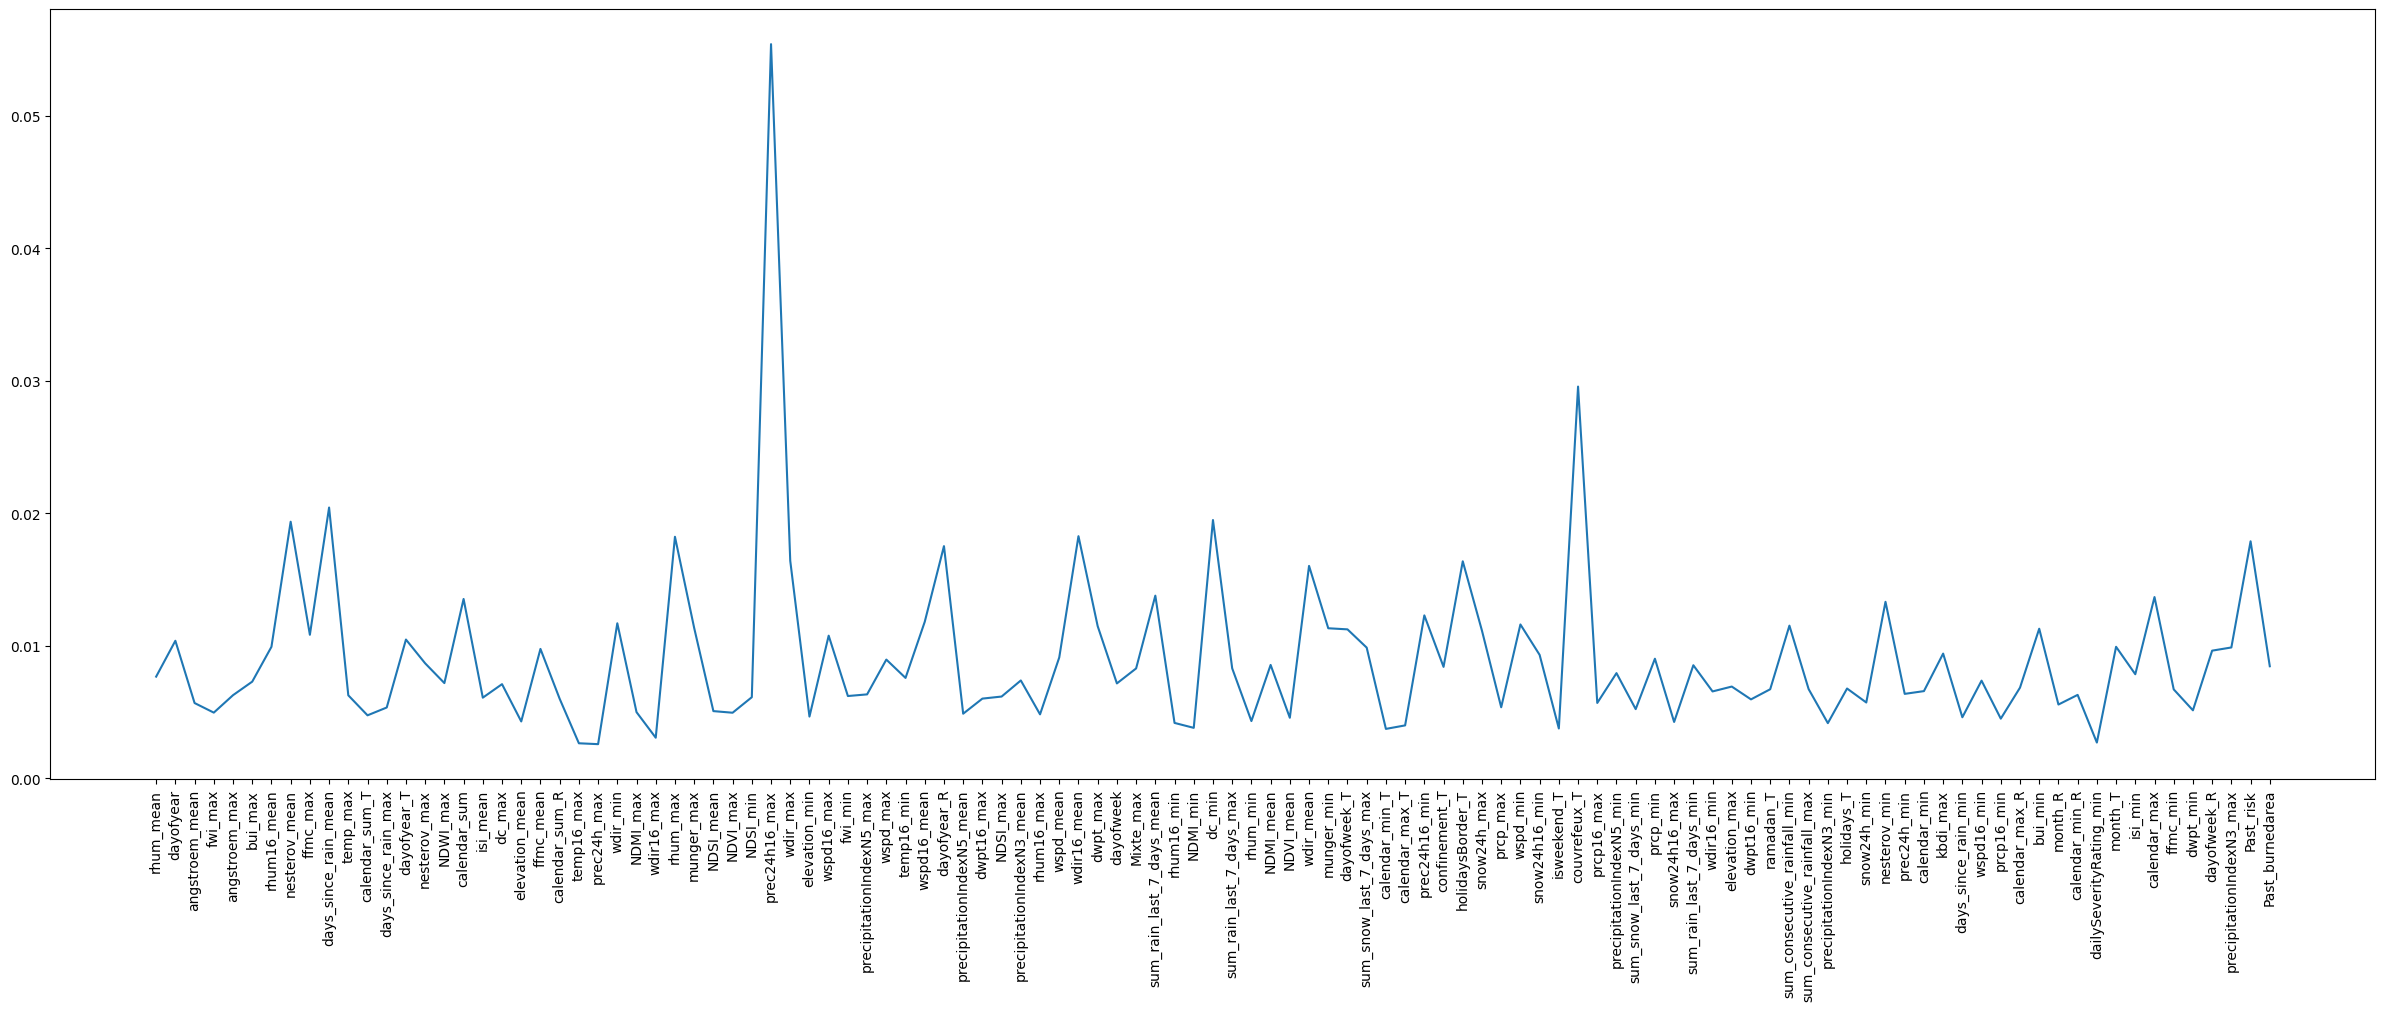

In [72]:
plt.figure(figsize=(30, 10))

plt.plot(average_sel)
plt.xticks(ticks=range(len(temporal_feature)), labels=temporal_feature, rotation=90)

plt.show()

In [73]:
avg = hidden['vsn_weights'].mean(dim=(0,1)).detach().cpu()
topk = torch.topk(avg, k=15)
for i, w in zip(topk.indices.tolist(), topk.values.tolist()):
    print(f"{temporal_feature[i]:30s} {w:.4f}")


prec24h16_max                  0.0554
couvrefeux_T                   0.0296
days_since_rain_mean           0.0204
dc_min                         0.0195
nesterov_mean                  0.0194
wdir16_mean                    0.0183
rhum_max                       0.0182
Past_risk                      0.0179
dayofyear_R                    0.0175
wdir_max                       0.0164
holidaysBorder_T               0.0164
wdir_mean                      0.0160
sum_rain_last_7_days_mean      0.0138
calendar_max                   0.0137
calendar_sum                   0.0135


<Axes: >

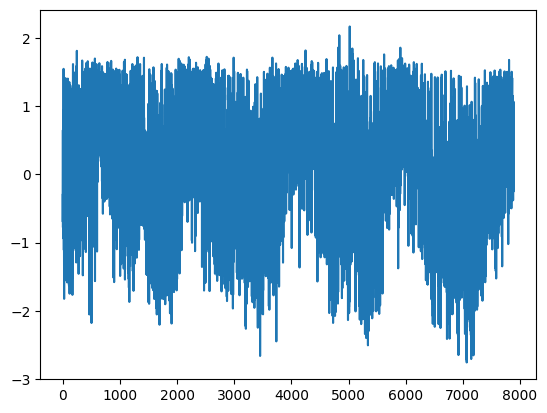

In [84]:
model.df_train['rhum_max'].plot()